In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
Stock_prices = pd.read_csv(r"C:\Users\Admin\Downloads\Stock_prices.csv")

In [4]:
Stock_prices

,symbol,date,open,high,low,close,volume
0,AAL,1/2/2014,25.07,25.82,25.06,25.36,8998943
1,AAPL,1/2/2014,79.38,79.58,78.86,79.02,58791957
2,AAP,1/2/2014,110.36,111.88,109.29,109.74,542711
3,ABBV,1/2/2014,52.12,52.33,51.52,51.98,4569061
4,ABC,1/2/2014,70.11,70.23,69.48,69.89,1148391
...,...,...,...,...,...,...,...
497467,XYL,12/29/2017,68.53,68.80,67.92,68.20,1046677
497468,YUM,12/29/2017,82.64,82.71,81.59,81.61,1347613
497469,ZBH,12/29/2017,121.75,121.95,120.62,120.67,1023624
497470,ZION,12/29/2017,51.28,51.55,50.81,50.83,1261916


In [6]:
X = Stock_prices[['open', 'high', 'low', 'close']]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

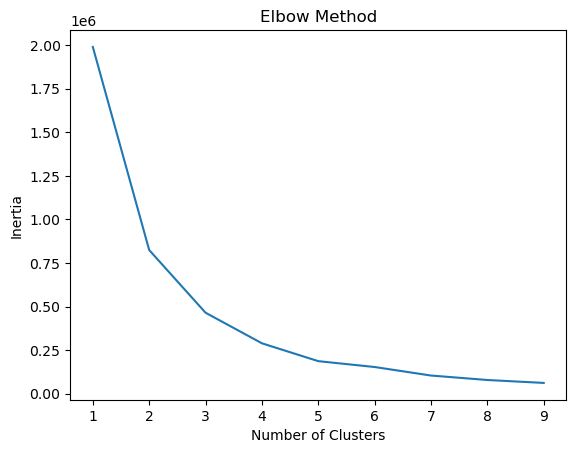

In [8]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
Stock_prices['cluster'] = kmeans.fit_predict(X_scaled)

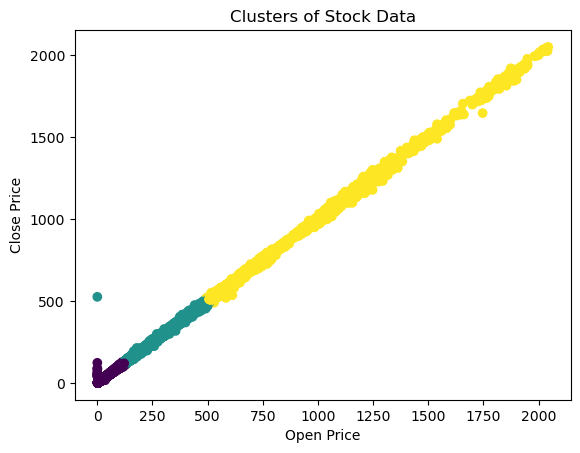

In [11]:
plt.scatter(Stock_prices['open'], Stock_prices['close'], c=Stock_prices['cluster'])
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Clusters of Stock Data")
plt.show()